# TimeGAN sample run

The main reference for this implementation is from [this notebook](https://github.com/jsyoon0823/TimeGAN/blob/master/tutorial_timegan.ipynb) by Jinsung Yoon.

For this project, it will be ran in a dedicated Python 3.7 environment since the code provided by Yoon runs on the legacy TensorFlow 1.x version.

## Import Libraries

In [15]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

## Load data Baranggay Agdao from CSV

In [16]:
brgy_agdao = pd.read_csv('brgy_agdao_pollutants_2018.csv')
brgy_agdao['pr'] = np.log1p(brgy_agdao['pr'])
brgy_agdao.head()

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "c:\Users\Mary Grace Bihag\anaconda3\envs\timegan_env\lib\site-packages\IPython\core\interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\Mary Grace Bihag\AppData\Local\Temp\ipykernel_18788\1470268792.py", line 1, in <module>
    brgy_agdao = pd.read_csv('brgy_agdao_pollutants_2018.csv')
  File "c:\Users\Mary Grace Bihag\anaconda3\envs\timegan_env\lib\site-packages\pandas\io\parsers.py", line 688, in read_csv
    return _read(filepath_or_buffer, kwds)
  File "c:\Users\Mary Grace Bihag\anaconda3\envs\timegan_env\lib\site-packages\pandas\io\parsers.py", line 454, in _read
    parser = TextFileReader(fp_or_buf, **kwds)
  File "c:\Users\Mary Grace Bihag\anaconda3\envs\timegan_env\lib\site-packages\pandas\io\parsers.py", line 948, in __init__
    self._make_engine(self.engine)
  File "c:\Users\Mary Grace Bihag\anaconda3\envs\timegan_env\lib\site-packages\pandas\io\parsers.py", line 1180,

TypeError: object of type 'NoneType' has no len()

## Time GAN Implementation

### Prerequisite
We must clone the official git repository of TimeGAN. Furthermore, as described in the original notebook, the necessary packages and function calls are as follows:

- timegan: Synthetic time-series data generation module
- data_loading: 2 real datasets and 1 synthetic datasets loading and preprocessing
- metrics:
    - discriminative_metrics: classify real data from synthetic data
    - predictive_metrics: train on synthetic, test on real
    - visualization: PCA and tSNE analyses

Since we will be using our own data in this project, we will be customizing the data_loading part.



In [ ]:
# 1. Clone the official TimeGAN repository
!git clone https://github.com/jsyoon0823/timeGAN.git

# 2. Move your terminal focus inside the newly created folder
%cd timeGAN

# 3. List the files to verify they downloaded successfully
!ls

c:\Users\Mary Grace Bihag\Desktop\Bayot Files\Eskwelabs\timeGAN


fatal: destination path 'timeGAN' already exists and is not an empty directory.
'ls' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
## Necessary packages
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# 1. TimeGAN model
from timeGAN.timegan import timegan

In [ ]:
from timeGAN.metrics.discriminative_metrics import discriminative_score_metrics
from timeGAN.metrics.predictive_metrics import predictive_score_metrics
from timeGAN.metrics.visualization_metrics import visualization

### Data Loading

In [ ]:
def MinMaxScaler(data):
  """Min Max normalizer.

  Args:
    - data: original data

  Returns:
    - norm_data: normalized data
  """
  numerator = data - np.min(data, 0)
  denominator = np.max(data, 0) - np.min(data, 0)
  norm_data = numerator / (denominator + 1e-7)
  return norm_data


def custom_data_loading (df, seq_len):
    """Load and preprocess real-world datasets.

    Args:
    - df: pandas dataframe
    - seq_len: sequence length

    Returns:
    - data: preprocessed data.
    """
    # Remove the header row
    ori_data = df.to_numpy()

    # Flip the data to make chronological data
    ori_data = ori_data[::-1]
    # Normalize the data
    ori_data = MinMaxScaler(ori_data)

    # Preprocess the dataset
    temp_data = []
    # Cut data by sequence length
    for i in range(0, len(ori_data) - seq_len):
        _x = ori_data[i:i + seq_len]
        temp_data.append(_x)

    # Mix the datasets (to make it similar to i.i.d)
    idx = np.random.permutation(len(temp_data))
    data = []
    for i in range(len(temp_data)):
        data.append(temp_data[idx[i]])

    return data

seq_len = 7
ori_data = custom_data_loading(brgy_agdao, seq_len)

### Set network parameters
TimeGAN network parameters should be optimized for different datasets.

- module: gru, lstm, or lstmLN
- hidden_dim: hidden dimensions
- num_layer: number of layers
- iteration: number of training iterations
- batch_size: the number of samples in each batch

In [ ]:
## Newtork parameters
parameters = dict()

parameters['module'] = 'gru'
parameters['hidden_dim'] = 64
parameters['num_layer'] = 3
parameters['iterations'] = 10000
parameters['batch_size'] = 128

### Run TimeGAN for synthetic time-series data generation
TimeGAN uses the original data and network parameters to return the generated synthetic data.

In [ ]:
# Run TimeGAN
generated_data = timegan(ori_data, parameters)
print('Finish Synthetic Data Generation')





Instructions for updating:
This class is equivalent as tf.keras.layers.GRUCell, and will be replaced by that in Tensorflow 2.0.
Instructions for updating:
This class is equivalent as tf.keras.layers.StackedRNNCells, and will be replaced by that in Tensorflow 2.0.
Instructions for updating:
Please use `keras.layers.RNN(cell)`, which is equivalent to this API
Instructions for updating:
Please use `layer.add_weight` method instead.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
The TensorFlow contrib module will not be included in TensorFlow 2.0.
For more information, please see:
  * https://github.com/tensorflow/community/blob/master/rfcs/20180907-contrib-sunset.md
  * https://github.com/tensorflow/addons


## Time GAN Evaluation

### 1. Discriminitive Score
To evaluate the classification accuracy between original and synthetic data using post-hoc RNN network. The output is |classification accuracy - 0.5|.

metric_iteration: the number of iterations for metric computation.

In [ ]:
metric_iteration = 5

discriminative_score = list()
for _ in range(metric_iteration):
  temp_disc = discriminative_score_metrics(ori_data, generated_data)
  discriminative_score.append(temp_disc)

print('Discriminative score: ' + str(np.round(np.mean(discriminative_score), 4)))

Instructions for updating:
Please use tf.global_variables instead.
Discriminative score: 0.1047


### 2. Predictive score
To evaluate the prediction performance on train on synthetic, test on real setting. More specifically, we use Post-hoc RNN architecture to predict one-step ahead and report the performance in terms of MAE.

In [ ]:
predictive_score = list()
for tt in range(metric_iteration):
  temp_pred = predictive_score_metrics(ori_data, generated_data)
  predictive_score.append(temp_pred)

print('Predictive score: ' + str(np.round(np.mean(predictive_score), 4)))


Predictive score: 0.1223


### 3. Visualization
We visualize the original and synthetic data distributions using PCA and tSNE analysis.

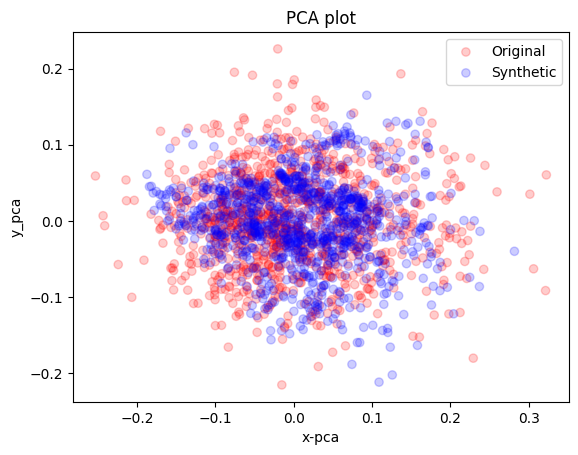

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 2000 samples in 0.014s...
[t-SNE] Computed neighbors for 2000 samples in 0.216s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2000
[t-SNE] Computed conditional probabilities for sample 2000 / 2000
[t-SNE] Mean sigma: 0.043519
[t-SNE] KL divergence after 250 iterations with early exaggeration: 72.728165
[t-SNE] KL divergence after 300 iterations: 1.705861


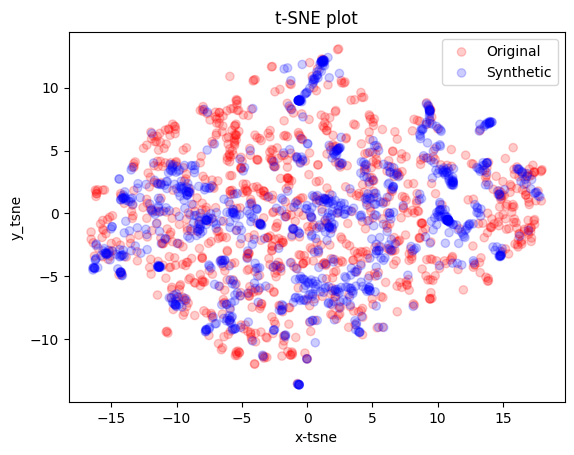

In [ ]:
visualization(ori_data, generated_data, 'pca')
visualization(ori_data, generated_data, 'tsne')

## Save the Generated Data

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# --- STEP 1: Re-fit the MinMaxScaler on your original data ---
scaler = MinMaxScaler()
scaler.fit(brgy_agdao)

# --- STEP 2: Reverse the MinMax Scaling ---
no, seq_len, dim = generated_data.shape
flattened_scaled = generated_data.reshape(-1, dim)
flattened_unscaled = scaler.inverse_transform(flattened_scaled)
unscaled_3d = flattened_unscaled.reshape(no, seq_len, dim)

# --- STEP 3: Smart-Flatten Overlapping Windows ---
# Take Day 0 from every sequence except the final sequence,
# then append the entire 30-day block of the final sequence to catch the end.
timeline_list = []
for i in range(no - 1):
    timeline_list.append(unscaled_3d[i, 0, :])  # Keep only the starting day

# Append the full last sequence to capture the final window smoothly
for t in range(seq_len):
    timeline_list.append(unscaled_3d[-1, t, :])

final_features = np.array(timeline_list)
total_days = final_features.shape[0]

# --- STEP 4: Generate the Date Tracker ---
# Now total_days will be around ~7,300, which seamlessly fits within Pandas
start_date = "2022-01-01"
date_range = pd.date_range(start=start_date, periods=total_days, freq='D')

# --- STEP 5: Build and Save the Final DataFrame ---
synthetic_df = pd.DataFrame(final_features, columns=brgy_agdao.columns)
synthetic_df.insert(0, 'Date', date_range)

# Save the file
synthetic_df.to_csv('synthetic_brgy_agdao_pollutants.csv', index=False)
print(f"Success! Cleaned overlap. Saved {total_days} days of synthetic weather records.")

Success! Cleaned overlap. Saved 1825 days of synthetic weather records.
